In [1138]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, concatenate
from tensorflow.keras.optimizers import Adam
import random
from collections import deque
import pandas as pd
import os
from datetime import datetime
import logging
import matplotlib.pyplot as plt

In [1139]:
# Configure logging
datetime_str = datetime.now().strftime("%Y_%m_%d")
i = 1
while True:
    path = f'./TD3_models/{datetime_str}/{i}'
    if not os.path.exists(path):
        os.makedirs(path)
        break
    else:
        i += 1

logging.basicConfig(filename=f'{path}/training.log', level=logging.INFO, format='%(asctime)s - %(message)s')

In [1140]:
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [1141]:
# Hyperparameters
STATE_SIZE = 4  # Open, Close, High, Low
ACTION_SIZE = 1  # Number of actions (e.g., buy, sell, hold)
BUFFER_SIZE = 50000  # Increased buffer size
BATCH_SIZE = 128  # Adjusted batch size
GAMMA = 0.995  # Adjusted discount factor
TAU = 0.002  # Adjusted soft update parameter
LR_ACTOR = 0.0003  # Adjusted learning rate for actor
LR_CRITIC = 0.0003  # Adjusted learning rate for critic
POLICY_NOISE = 0.3  # Adjusted policy noise
NOISE_CLIP = 0.8  # Adjusted noise clip
POLICY_FREQ = 1  # Adjusted policy update frequency
EXPLORATION_NOISE = 0.3  # Adjusted exploration noise
LEARNING_RATE = 0.0002  # Adjusted learning rate

In [1142]:
# Budget
BUDGET = 1000000  #1,000,000

In [1143]:
class StockTradingEnvironment:
    def __init__(self, data, budget=BUDGET):
        self.data = data[['Open', 'Close', 'High', 'Low']].values
        self.data_mean = np.mean(self.data, axis=0)
        self.data_std = np.std(self.data, axis=0)
        self.data = (self.data - self.data_mean) / (self.data_std + 1e-8)  # Normalization
        # Add technical indicators
        self.data = self._add_technical_indicators(data)
        self.budget = budget
        self.index = 0
        self.position = 0
        self.portfolio_value = budget
        
    def _add_technical_indicators(self, data):
        data['SMA_5'] = data['Close'].rolling(window=5).mean()
        data['SMA_10'] = data['Close'].rolling(window=10).mean()
        data['SMA_20'] = data['Close'].rolling(window=20).mean()
        data = data.dropna()  # Drop rows with NaN values
        tech_indicators = data[['SMA_5', 'SMA_10', 'SMA_20']].values
        tech_indicators_mean = np.mean(tech_indicators, axis=0)
        tech_indicators_std = np.std(tech_indicators, axis=0)
        tech_indicators = (tech_indicators - tech_indicators_mean) / (tech_indicators_std + 1e-8)  # Normalization
        self.data = data[['Open', 'Close', 'High', 'Low']].values  # Update self.data to match the length of tech_indicators
        self.data = (self.data - self.data_mean) / (self.data_std + 1e-8)  # Re-normalize the updated self.data
        self.data = np.hstack((self.data, tech_indicators))
        return self.data

    def reset(self):
        self.index = 0
        self.position = 0
        self.portfolio_value = self.budget
        return self._get_state()

    def step(self, action):
        done = False
        reward = 0
        current_price = self.data[self.index, 1]  # Close price

        if action == 0:  # Hold
            reward = 0  # No reward for holding
        elif action == 1:  # Buy
            max_buyable_quantity = min(self.budget // current_price, 100)  # Limit buy quantity
            if max_buyable_quantity > 0:
                self.position += max_buyable_quantity
                self.budget -= max_buyable_quantity * current_price
                reward = -max_buyable_quantity * current_price  # Negative reward for buying
        elif action == 2:  # Sell
            if self.position > 0:
                max_sellable_quantity = min(self.position, 100)  # Limit sell quantity
                self.position -= max_sellable_quantity
                self.budget += max_sellable_quantity * current_price
                reward = max_sellable_quantity * current_price  # Positive reward for selling
            else:
                reward = 0  # No reward if trying to sell with zero position

        previous_portfolio_value = self.portfolio_value
        self.portfolio_value = self.budget + self.position * current_price

        # Calculate reward based on the change in portfolio value
        reward += (self.portfolio_value - previous_portfolio_value) / 10000  # Scaling the reward

        if self.index == len(self.data) - 1:
            done = True
        else:
            self.index += 1

        next_state = self._get_state()
        logging.info(f"Step: Action={'Buy' if action == 1 else 'Sell' if action == 2 else 'Hold'}, Reward={reward}, Portfolio Value={self.portfolio_value}, Budget={self.budget}, Position={self.position}")
        return next_state, reward, done

    def _get_state(self):
        return self.data[self.index]

In [1144]:
class ReplayBuffer:
    def __init__(self, buffer_size):
        self.buffer = deque(maxlen=buffer_size)

    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = map(np.array, zip(*batch))
        return states, actions, rewards, next_states, dones

In [1145]:
class Actor(Model):
    def __init__(self, action_size):
        super(Actor, self).__init__()
        self.fc1 = Dense(512, activation='relu')
        self.fc2 = Dense(256, activation='relu')
        self.action = Dense(action_size, activation='tanh')

    def call(self, state):
        x = self.fc1(state)
        x = self.fc2(x)
        action = self.action(x)
        return action

class Critic(Model):
    def __init__(self):
        super(Critic, self).__init__()
        self.fc1 = Dense(512, activation='relu')
        self.fc2 = Dense(256, activation='relu')
        self.q = Dense(1, activation=None)

    def call(self, state, action):
        action = tf.reshape(action, [-1, 1])  # Reshape action to match the state tensor
        x = concatenate([state, action], axis=-1)
        x = self.fc1(x)
        x = self.fc2(x)
        q = self.q(x)
        return q

In [1146]:
class TD3Agent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.actor = Actor(action_size)
        self.critic1 = Critic()
        self.critic2 = Critic()
        self.target_actor = Actor(action_size)
        self.target_critic1 = Critic()
        self.target_critic2 = Critic()
        self.actor_optimizer = Adam(LEARNING_RATE)
        self.critic1_optimizer = Adam(LEARNING_RATE)
        self.critic2_optimizer = Adam(LEARNING_RATE)
        self.replay_buffer = ReplayBuffer(BUFFER_SIZE)
        self.update_target_networks(tau=1)
        self.train_step = 0  # Initialize train_step
        self.exploration_noise = EXPLORATION_NOISE
        self.learning_rate_decay = 0.99995  # Adjusted learning rate decay factor

    def update_target_networks(self, tau=TAU):
        actor_weights = self.actor.get_weights()
        target_actor_weights = self.target_actor.get_weights()
        for i in range(len(actor_weights)):
            target_actor_weights[i] = tau * actor_weights[i] + (1 - tau) * target_actor_weights[i]
        self.target_actor.set_weights(target_actor_weights)

        critic1_weights = self.critic1.get_weights()
        target_critic1_weights = self.target_critic1.get_weights()
        for i in range(len(critic1_weights)):
            target_critic1_weights[i] = tau * critic1_weights[i] + (1 - tau) * target_critic1_weights[i]
        self.target_critic1.set_weights(target_critic1_weights)

        critic2_weights = self.critic2.get_weights()
        target_critic2_weights = self.target_critic2.get_weights()
        for i in range(len(critic2_weights)):
            target_critic2_weights[i] = tau * critic2_weights[i] + (1 - tau) * target_critic2_weights[i]
        self.target_critic2.set_weights(target_critic2_weights)

    def select_action(self, state):
        state = np.expand_dims(state, axis=0)
        action = self.actor(state).numpy()[0]
        
        # Add exploration noise
        noise = np.random.normal(0, self.exploration_noise)
        action = np.clip(action + noise, -1, 1)
        
        # Map continuous action to discrete action (0: Hold, 1: Buy, 2: Sell)
        if action < -0.33:
            discrete_action = 2  # Sell
        elif action > 0.33:
            discrete_action = 1  # Buy
        else:
            discrete_action = 0  # Hold
        
        return discrete_action

    def train(self):
        if len(self.replay_buffer.buffer) < BATCH_SIZE:
            return

        states, actions, rewards, next_states, dones = self.replay_buffer.sample(BATCH_SIZE)

        next_actions = self.target_actor(next_states)
        noise = np.random.normal(0, POLICY_NOISE, size=next_actions.shape)
        noise = np.clip(noise, -NOISE_CLIP, NOISE_CLIP)
        next_actions = next_actions + noise
        next_actions = np.clip(next_actions, -1, 1)

        target_q1 = self.target_critic1(next_states, next_actions).numpy()
        target_q2 = self.target_critic2(next_states, next_actions).numpy()
        target_q = np.minimum(target_q1, target_q2)
        target_q = rewards + (1 - dones) * GAMMA * target_q

        with tf.GradientTape() as tape1, tf.GradientTape() as tape2:
            q1 = self.critic1(states, actions)
            q2 = self.critic2(states, actions)
            critic1_loss = tf.reduce_mean((q1 - target_q) ** 2)
            critic2_loss = tf.reduce_mean((q2 - target_q) ** 2)

        critic1_grads = tape1.gradient(critic1_loss, self.critic1.trainable_variables)
        critic2_grads = tape2.gradient(critic2_loss, self.critic2.trainable_variables)
        self.critic1_optimizer.apply_gradients(zip(critic1_grads, self.critic1.trainable_variables))
        self.critic2_optimizer.apply_gradients(zip(critic2_grads, self.critic2.trainable_variables))

        actor_loss = 0.0  # Initialize actor_loss with a default value

        if self.train_step % POLICY_FREQ == 0:
            with tf.GradientTape() as tape:
                actor_actions = self.actor(states)
                actor_loss = -tf.reduce_mean(self.critic1(states, actor_actions))

            actor_grads = tape.gradient(actor_loss, self.actor.trainable_variables)
            self.actor_optimizer.apply_gradients(zip(actor_grads, self.actor.trainable_variables))

            self.update_target_networks()

        self.train_step += 1
        self.exploration_noise *= 0.9995  # Gradually reduce exploration noise
        self.actor_optimizer.learning_rate *= self.learning_rate_decay  # Apply learning rate decay
        self.critic1_optimizer.learning_rate *= self.learning_rate_decay  # Apply learning rate decay
        self.critic2_optimizer.learning_rate *= self.learning_rate_decay  # Apply learning rate decay

        # Logging losses
        actor_loss_value = actor_loss if isinstance(actor_loss, tf.Tensor) else tf.constant(actor_loss, dtype=tf.float32)
        logging.info(f"Train Step: {self.train_step}, Actor Loss: {actor_loss_value.numpy()}, Critic1 Loss: {critic1_loss.numpy()}, Critic2 Loss: {critic2_loss.numpy()}")

    def add_to_buffer(self, state, action, reward, next_state, done):
        self.replay_buffer.add(state, action, reward, next_state, done)

    def save_models(self, path):
        # Save the models
        self.actor.save(f'{path}/actor_model.h5')
        self.critic1.save(f'{path}/critic1_model.h5')
        self.critic2.save(f'{path}/critic2_model.h5')

    def load_models(self, path):
        self.actor = tf.keras.models.load_model(path + '_actor.h5')
        self.critic1 = tf.keras.models.load_model(path + '_critic1.h5')
        self.critic2 = tf.keras.models.load_model(path + '_critic2.h5')
        self.target_actor = tf.keras.models.load_model(path + '_actor.h5')
        self.target_critic1 = tf.keras.models.load_model(path + '_critic1.h5')
        self.target_critic2 = tf.keras.models.load_model(path + '_critic2.h5')

In [1147]:
def train_agent(agent, env, episodes):
    episode_rewards = []
    evaluation_rewards = []
    best_reward = -float('inf')
    patience = 10  # Increased patience
    no_improvement_count = 0

    for episode in range(episodes):
        state = env.reset()
        total_reward = 0
        done = False

        while not done:
            action = agent.select_action(state)
            next_state, reward, done = env.step(action)
            agent.add_to_buffer(state, action, reward, next_state, done)
            agent.train()
            state = next_state
            total_reward += reward

        episode_rewards.append(total_reward)

        if total_reward > best_reward:
            best_reward = total_reward
            no_improvement_count = 0
        else:
            no_improvement_count += 1

        if no_improvement_count >= patience:
            logging.info(f"Early stopping at episode {episode + 1}")
            print(f"Early stopping at episode {episode + 1}")
            break

        logging.info(f"Episode: {episode + 1}, Total Reward: {total_reward}")
        logging.info('-' * 50)
        print(f"Episode: {episode + 1}, Total Reward: {total_reward}")

        # Evaluate the agent periodically
        if episode % 10 == 0:
            average_reward = evaluate_agent(agent, env, episodes=10)
            evaluation_rewards.append(average_reward)
            logging.info(f"Evaluation at Episode {episode + 1}: Average Reward: {average_reward}")
            print(f"Evaluation at Episode {episode + 1}: Average Reward: {average_reward}")
        
    agent.save_models(path)

    return episode_rewards, evaluation_rewards

In [1148]:
def evaluate_agent(agent, env, episodes):
    total_rewards = []
    for episode in range(episodes):
        state = env.reset()
        total_reward = 0
        done = False

        while not done:
            action = agent.select_action(state)
            next_state, reward, done = env.step(action)
            state = next_state
            total_reward += reward

        total_rewards.append(total_reward)
    return np.mean(total_rewards)

In [1149]:
data = pd.read_csv('./datas/samsung.csv')  # Load your stock data here

In [1150]:
env = StockTradingEnvironment(data)
agent = TD3Agent(STATE_SIZE, ACTION_SIZE)

In [1151]:
# Clear the log file
with open('./training.log', 'w') as f:
    f.truncate(0)

In [ ]:
episode_rewards, evaluation_rewards = train_agent(agent, env, episodes=50)

Episode: 1, Total Reward: -1120.9173603994452
Evaluation at Episode 1: Average Reward: -43.71734174251956
Episode: 2, Total Reward: -4764.798546337459
Episode: 3, Total Reward: -6969.904279993439


In [ ]:
def visualize_training_report(episode_rewards, evaluation_rewards, episodes):
    plt.figure(figsize=(12, 6))

    # Plot episode rewards
    plt.subplot(1, 2, 1)
    plt.plot(episode_rewards)
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.title('Learning Curve')

    # Plot evaluation rewards
    plt.subplot(1, 2, 2)
    plt.plot(range(0, episodes, 10), evaluation_rewards, marker='o')
    plt.xlabel('Episode')
    plt.ylabel('Average Evaluation Reward')
    plt.title('Evaluation Rewards')

    plt.tight_layout()
    plt.show()

ValueError: x and y must have same first dimension, but have shapes (10,) and (1,)

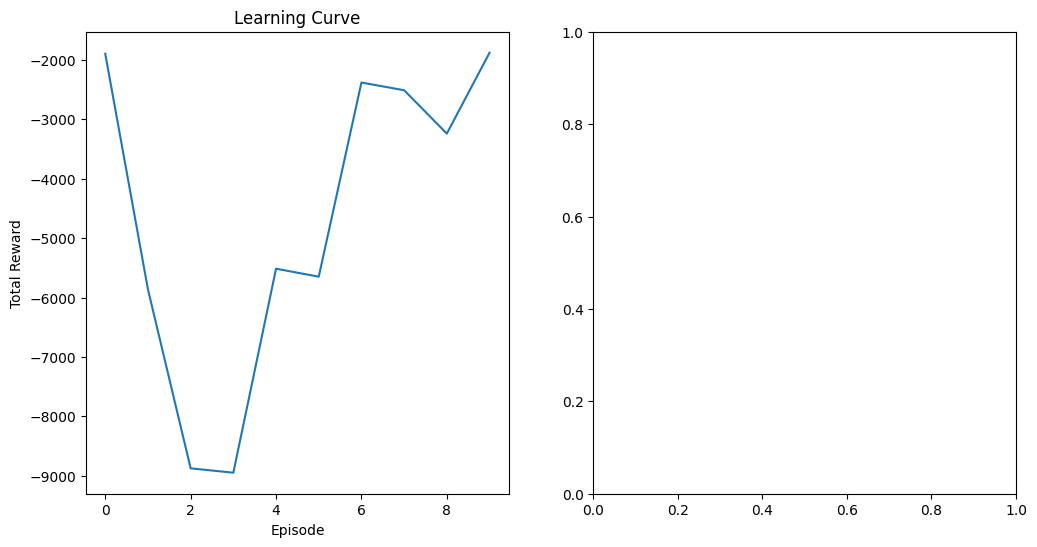

In [1105]:
visualize_training_report(episode_rewards, evaluation_rewards, episodes=100)

In [ ]:
# Evaluate the agent after training
average_reward = evaluate_agent(agent, env, episodes=10)
print(f"Average Evaluation Reward: {average_reward}")